# Hypothesis Testing - Smoking Data

EDA를 통해 도출된 인사이트를 기반으로 흡연 여부(label)와 주요 변수 간의 관계를 통계적으로 검증한다.

## 목표
- EDA에서 관찰된 패턴이 통계적으로 유의한지 검증
- 변수와 흡연 여부 간의 관계를 객관적으로 판단
- 향후 모델링을 위한 feature 이해도 향상

In [47]:
# 경로 추가
import sys
import os

sys.path.append(os.path.abspath(".."))

In [48]:
# 라이브러리 & 데이터 로드
import pandas as pd
import numpy as np
import scipy.stats as stats

# 전처리 함수 import
from src.preprocessing import preprocess_data

# 시각화 함수 import
from src.visualization import (
    plot_numeric_vs_target,
    plot_categorical_vs_target
)

# 데이터 로드
df = pd.read_csv("../data/raw/smoking_health_data.csv")

# 전처리 적용
df = preprocess_data(df)

df.head()

,ID,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,중성 지방_log
0,TRAIN_0000,35,170,70,24.22,1.10,1,98.0,40.0,80.0,1.3,211,75,120,15.9,1,1.53,1,4.394449
1,TRAIN_0001,40,150,55,24.44,1.00,0,173.0,39.0,104.0,0.6,251,46,184,11.8,1,1.45,0,4.653960
2,TRAIN_0002,60,170,50,17.30,0.75,0,96.0,40.0,61.0,0.8,144,43,89,15.3,1,1.04,0,4.127134
3,TRAIN_0003,40,150,45,20.00,0.50,0,92.0,40.0,46.0,0.7,178,66,110,13.4,1,1.18,0,3.850148
4,TRAIN_0004,55,155,65,27.06,1.20,0,87.0,42.0,95.0,0.9,232,62,151,13.8,1,1.32,0,4.564348


## 전처리 결과 확인

EDA에서 확인했던 데이터 이슈(결측치, 이상치, 분포 왜곡 등)가 전처리를 통해 어떻게 변화했는지 확인

=== 전처리 후 기본 통계 ===


,나이,키(cm),몸무게(kg),BMI,시력,충치,공복 혈당,혈압,중성 지방,혈청 크레아티닌,콜레스테롤,고밀도지단백,저밀도지단백,헤모글로빈,요 단백,간 효소율,label,중성 지방_log
count,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00,7000.00
mean,43.97,164.78,65.93,24.14,1.00,0.23,99.24,45.89,126.63,0.88,197.28,57.36,114.59,14.64,1.08,1.14,0.37,4.70
std,12.06,9.17,12.98,3.50,0.31,0.42,20.98,8.32,72.54,0.18,36.31,14.51,33.04,1.50,0.39,0.43,0.48,0.54
min,20.00,135.00,30.00,14.27,0.10,0.00,57.00,30.00,21.00,0.50,86.00,18.00,26.00,10.45,1.00,0.14,0.00,3.09
25%,35.00,160.00,55.00,21.60,0.80,0.00,89.00,40.00,74.00,0.80,173.00,47.00,92.00,13.60,1.00,0.84,0.00,4.32
50%,40.00,165.00,65.00,23.88,1.00,0.00,96.00,45.00,107.00,0.90,195.00,55.00,113.00,14.80,1.00,1.10,0.00,4.68
75%,50.00,170.00,75.00,26.12,1.20,0.00,103.00,50.00,160.00,1.00,219.00,66.00,136.00,15.70,1.00,1.38,1.00,5.08
max,85.00,190.00,130.00,42.45,2.50,1.00,386.00,91.00,399.00,1.30,395.00,157.00,202.00,18.85,5.00,5.67,1.00,5.99



=== 전처리 후 결측치 ===
ID           0
나이           0
키(cm)        0
몸무게(kg)      0
BMI          0
시력           0
충치           0
공복 혈당        0
혈압           0
중성 지방        0
혈청 크레아티닌     0
콜레스테롤        0
고밀도지단백       0
저밀도지단백       0
헤모글로빈        0
요 단백         0
간 효소율        0
label        0
중성 지방_log    0
dtype: int64


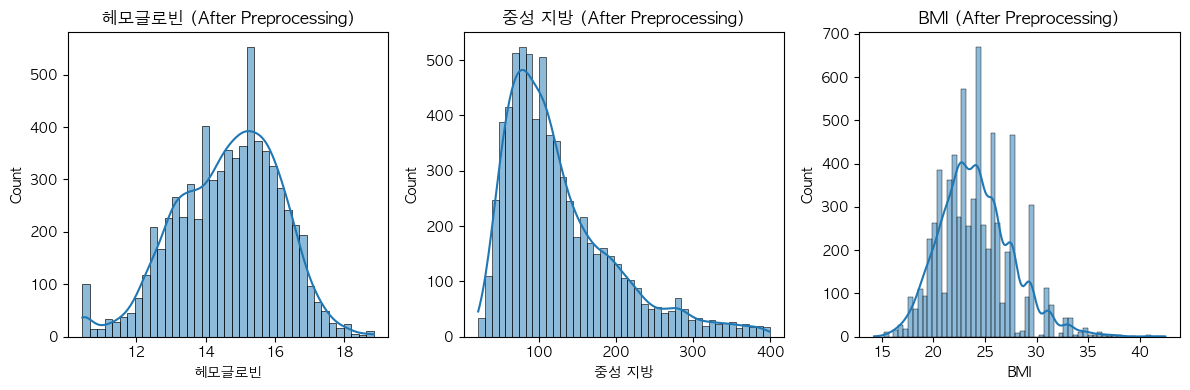

In [49]:
# 요약 통계
print("=== 전처리 후 기본 통계 ===")
display(df.describe().round(2))

# 결측치 확인
print("\n=== 전처리 후 결측치 ===")
print(df.isnull().sum())

# 분포 확인 (핵심 변수만)
import matplotlib.pyplot as plt
import seaborn as sns

cols = ["헤모글로빈", "중성 지방", "BMI"]

plt.figure(figsize=(12, 4))

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} (After Preprocessing)")

plt.tight_layout()
plt.show()


### 전처리 결과 해석

전처리 이후 주요 변수(헤모글로빈, 중성 지방, BMI)의 분포를 확인한 결과, EDA 단계에서 확인되었던 결측치 및 이상치 문제가 전반적으로 완화된 것을 확인할 수 있었다.

- 헤모글로빈:
  - 분포가 종형에 가까운 형태로 나타나며, 극단값이 제거되어 변동성이 안정됨
  
  → 평균 기반 통계 분석(t-test)에 적합한 분포 형태를 확보

- 중성 지방:
  - 여전히 오른쪽으로 치우친 분포를 보이지만, 로그 변환 및 이상치 처리로 인해 극단값의 영향이 감소함
  
  → 순위 기반 분석(Spearman) 및 비모수 검정에 적합한 구조 유지

- BMI:
  - 비정상적으로 낮거나 높은 값(BMI < 15, BMI > 45)을 제거하여 현실적인 범위로 정제됨
  - 전반적으로 안정적인 종형 분포를 유지하며, 비만 여부 기준(25)을 중심으로 집단 구분이 가능

- 몸무게:
  - 성인 기준에서 비현실적인 저체중 값(40kg 미만)을 제거하여 데이터 신뢰도를 향상시킴

종합적으로, 전처리를 통해 데이터의 신뢰성과 일관성이 향상되었으며, 통계적 가설 검정을 수행하기에 적절한 상태로 정제되었다.

→ 따라서 이후 분석 결과는 극단값에 의한 왜곡 없이 보다 안정적으로 해석할 수 있다.

## 가설 설정

EDA 결과를 기반으로 파생변수를 생성하고, 이를 바탕으로 다음과 같은 가설을 수립하였다.

### 가설 1 (헤모글로빈)
- H₀ (귀무가설): 흡연자와 비흡연자의 평균 헤모글로빈 수치는 차이가 없다
- H₁ (대립가설): 흡연자와 비흡연자의 평균 헤모글로빈 수치는 차이가 있다

### 가설 2 (중성 지방 - 순위 관계)
- H₀ (귀무가설): 흡연 여부와 중성지방 간 순위 상관관계가 없다
- H₁ (대립가설): 흡연 여부와 중성지방 간 순위 상관관계가 있다

### 가설 3 (BMI 기반 조건부 분석)
- H₀ (귀무가설): 비만 집단에서 흡연자와 비흡연자의 중성지방 평균은 차이가 없다
- H₁ (대립가설): 비만 집단에서 흡연자와 비흡연자의 중성지방 평균은 차이가 있다

### 가설 4 (충치)
- H₀: 흡연 여부와 충치 발생 여부는 독립이다
- H₁: 흡연 여부와 충치 발생 여부는 독립이 아니다

※ 유의수준(alpha) = 0.05

In [50]:
# 파생변수 생성

# BMI 기반 비만 여부
df["비만 여부"] = (df["BMI"] >= 25).astype(int)

# 확인
df[["BMI", "비만 여부"]].head()

,BMI,비만 여부
0,24.22,0
1,24.44,0
2,17.30,0
3,20.00,0
4,27.06,1


## 가설 검정

In [51]:
# 가설 1
alpha = 0.05

group0 = df[df["label"] == 0]["헤모글로빈"].dropna()
group1 = df[df["label"] == 1]["헤모글로빈"].dropna()

print("=== 정규성 검정 (Shapiro) ===")
print("Non-smoker:", stats.shapiro(group0))
print("Smoker:", stats.shapiro(group1))

t_stat, p_value = stats.ttest_ind(group0, group1, equal_var=False)

print("\n=== 가설 1: 헤모글로빈 ===")
print(f"Mean (Non-smoker): {group0.mean():.2f}")
print(f"Mean (Smoker):     {group1.mean():.2f}")
print(f"p-value: {p_value:.4f}")

if p_value < alpha:
    print("→ 귀무가설 기각: 유의미한 차이 있음")
else:
    print("→ 귀무가설 채택: 차이 없음")

=== 정규성 검정 (Shapiro) ===
Non-smoker: ShapiroResult(statistic=np.float64(0.9927300479108644), pvalue=np.float64(3.004634385802879e-14))
Smoker: ShapiroResult(statistic=np.float64(0.991570592785576), pvalue=np.float64(4.15606184976745e-11))

=== 가설 1: 헤모글로빈 ===
Mean (Non-smoker): 14.18
Mean (Smoker):     15.44
p-value: 0.0000
→ 귀무가설 기각: 유의미한 차이 있음


In [52]:
# 가설 2
rho, p_value = stats.spearmanr(df["label"], df["중성 지방_log"])

print("\n=== 가설 2: 중성지방 (순위 상관) ===")
print(f"Spearman rho: {rho:.4f}")
print(f"p-value: {p_value:.4f}")

if abs(rho) < 0.1:
    print("→ 매우 약한 상관관계")
elif abs(rho) < 0.3:
    print("→ 약한 상관관계")
elif abs(rho) < 0.5:
    print("→ 중간 정도 상관관계")
else:
    print("→ 강한 상관관계")

if p_value < alpha:
    print("→ 귀무가설 기각")
else:
    print("→ 귀무가설 채택")


=== 가설 2: 중성지방 (순위 상관) ===
Spearman rho: 0.2497
p-value: 0.0000
→ 약한 상관관계
→ 귀무가설 기각


In [53]:
# 가설 3
obese = df[df["비만 여부"] == 1]

g0 = obese[obese["label"] == 0]["중성 지방"].dropna()
g1 = obese[obese["label"] == 1]["중성 지방"].dropna()

print("\n=== 가설 3: 비만 집단 ===")
print(f"Sample size (Non-smoker): {len(g0)}")
print(f"Sample size (Smoker): {len(g1)}")

t_stat, p_value = stats.ttest_ind(g0, g1, equal_var=False)

print(f"Mean (Non-smoker): {g0.mean():.2f}")
print(f"Mean (Smoker):     {g1.mean():.2f}")
print(f"p-value: {p_value:.4f}")

if p_value < alpha:
    print("→ 귀무가설 기각: 차이 있음")
else:
    print("→ 귀무가설 채택: 차이 없음")


=== 가설 3: 비만 집단 ===
Sample size (Non-smoker): 1363
Sample size (Smoker): 1093
Mean (Non-smoker): 140.44
Mean (Smoker):     172.93
p-value: 0.0000
→ 귀무가설 기각: 차이 있음


In [54]:
# 가설 4
ct = pd.crosstab(df["label"], df["충치"])

chi2, p_value, dof, expected = stats.chi2_contingency(ct)

print("\n=== 가설 4: 충치 ===")
print(ct)
print(f"Chi2: {chi2:.4f}")
print(f"dof: {dof}")
print(f"p-value: {p_value:.4f}")

print("\nExpected frequencies:")
print(expected)

if p_value < alpha:
    print("→ 귀무가설 기각: 연관성 있음")
else:
    print("→ 귀무가설 채택: 연관성 없음")


=== 가설 4: 충치 ===
충치        0    1
label           
0      3561  868
1      1847  724
Chi2: 67.3857
dof: 1
p-value: 0.0000

Expected frequencies:
[[3421.71885714 1007.28114286]
 [1986.28114286  584.71885714]]
→ 귀무가설 기각: 연관성 있음


In [55]:
# =========================
# 최종 데이터 저장
# =========================
from src.feature_engineering import feature_engineering, save_featured_data

# feature engineering 적용
df_final = feature_engineering(df)

# 저장
save_featured_data(df_final, "../data/processed/smoking_processed.csv")

print("최종 데이터 저장 완료!")

최종 데이터 저장 완료!
